In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import numpy as np
import control as ct
import pandas as pd

from   scipy.linalg import block_diag
from   matplotlib import pyplot as plt
from   collections import namedtuple

import utils_data

In [2]:
# --! read data from files --!

data_path = '../../data/delay/detuning_24-03-2025_15-54_2'
data_frame = pd.read_csv(data_path, skiprows=23, dtype=np.float32, sep='\t', decimal=',')
detuning_data = data_frame.to_numpy()

data_path = '../../data/delay/gun_data2_w_kick_fft.csv'
data_frame = pd.read_csv(data_path, dtype=np.float32, sep=' ')
fft_with_kick = data_frame.to_numpy()

data_path = '../../data/delay/gun_data2_wo_kick_fft.csv'
dataframe = pd.read_csv(data_path, dtype=np.float32, sep=' ')
fft_without_kick = dataframe.to_numpy()

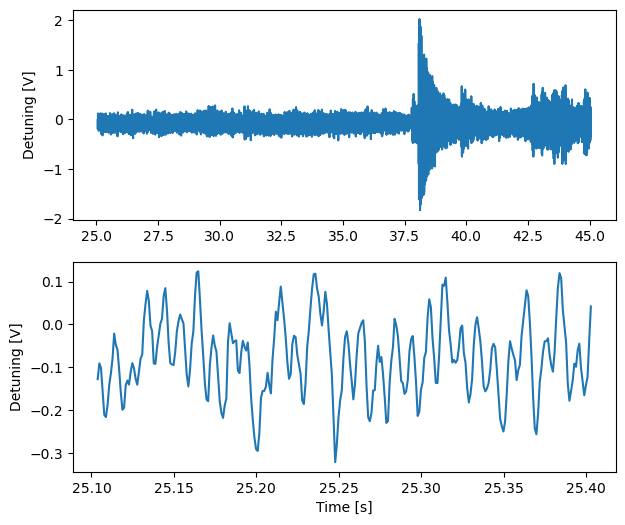

In [3]:
plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.plot(detuning_data[:, 0], detuning_data[:, 1])
plt.ylabel('Detuning [V]')

plt.subplot(2,1,2)
plt.plot(detuning_data[50:350, 0], detuning_data[50:350, 1])
plt.ylabel('Detuning [V]')
plt.xlabel('Time [s]')

plt.show()

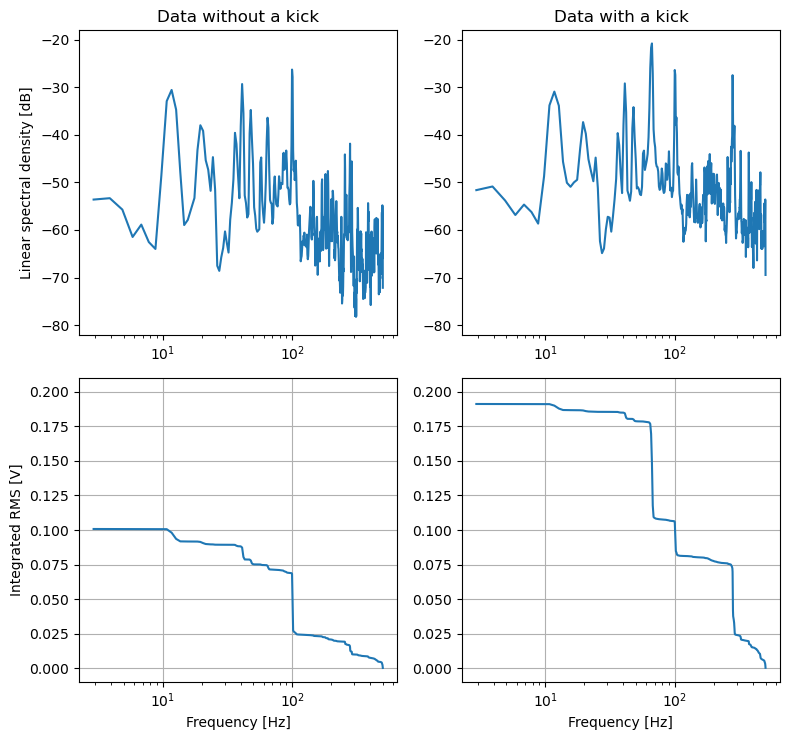

In [4]:
plt.figure(figsize=(8, 7.5))

plt.subplot(2,2,1)
plt.title('Data without a kick')
plt.semilogx(fft_without_kick[:, 0], fft_without_kick[:, 1])
plt.ylim((-82,-18))
plt.ylabel('Linear spectral density [dB]')
plt.subplot(2,2,2)
plt.title('Data with a kick')
plt.semilogx(fft_with_kick[:, 0], fft_with_kick[:, 1])
plt.ylim((-82,-18))

plt.subplot(2,2,3)
plt.semilogx(fft_without_kick[:, 0], fft_without_kick[:, 2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Integrated RMS [V]')
plt.ylim((-0.01, 0.21))
plt.grid()
plt.subplot(2,2,4)
plt.semilogx(fft_with_kick[:, 0], fft_with_kick[:, 2])
plt.xlabel('Frequency [Hz]')
plt.ylim((-0.01, 0.21))
plt.grid()

plt.tight_layout()
plt.show()

In [5]:
# --! constructors for rf and mechanical mode matrices --!

def make_rf_a(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [-hbw,     0.],
        [ 0.,    -hbw],
    ])

def make_rf_b(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [hbw,    0.],
        [0.,    hbw],
    ])

def make_mm_a(f, q):
    """Constructs the matrix A of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q],
    ])

def make_mm_b(f, k):
    """Constructs the matrix B of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [0               ],
        [k * np.square(w)],
    ])

def make_pzt(bw):
    tau = 1 / (2 * np.pi * bw)
    a = np.array([[-1 / tau]])
    b = np.array([[1 / tau]])
    c = np.array([[1]])
    d = np.array([[0]])

    return ct.ss(a, b, c, d)

def make_mm_plant(f=np.array([100.]), q=np.array([1000.]), k=np.array([1.])):
    a = block_diag(*[make_mm_a(f, q) for f, q in zip(f, q)])
    b = np.concatenate([make_mm_b(f, k) for f, k in zip(f, k)], axis=0)
    c = np.tile(np.array([[1, 0]]), len(f))
    d = np.array(([[0]]))

    return ct.ss(a, b, c, d)

def cavity_update(t, x, u, param):

    # --! get parameters
    rf_f = param.get('rf_f')
    rf_q = param.get('rf_q')
    rf_v = param.get('rf_v')
    rf_len = param.get('rf_len')
    mm_control_used = param.get('mm_control_used')
    mm_f = param.get('mm_f')
    mm_q = param.get('mm_q')
    nmm = len(mm_f)
    mm_k = param.get('mm_k')
    mm_t = param.get('mm_t')

    # --! extract current state of a cavity field: real and imaginary components
    rf_x = np.array(x[:2]).reshape((-1, 1))

    # --! extract current states of all mechanical modes: displacements and velocities
    mm_x = np.array(x[2:]).reshape((-1, 1))

    # --! assemble input to cavity field: real and imaginary parts of a generator voltage
    rf_u = np.array([
        [rf_v[0]],
        [rf_v[1]]
    ])

    # --! compute input to mechanical mode: accelerating field gradient squared
    #
    # --! field gradient has units MV/m, but since we simulate only one cell,
    # --! and the length of one cell is passed as a parameter,
    # --! we need to adjust the total gradient
    rf_grad = np.sqrt(np.square(rf_x[0]) + np.square(rf_x[1]))
    rf_grad = rf_grad * rf_len
    rf_grad = np.square(rf_grad)

    # --! mechanical modes are excited by field gradient ...
    mm_u = rf_grad
    if mm_control_used:
        # --! ... and compensated by control (if used)
        mm_u = mm_u + u

    # --! create rf matrices A and B
    rf_a = make_rf_a(rf_f, rf_q)
    rf_b = make_rf_b(rf_f, rf_q)

    # --! update detuning in rf matrix A
    mm_disp = np.sum([mm_x[2*j] for j in range(nmm)])
    rf_a[0, 1] = -mm_disp
    rf_a[1, 0] =  mm_disp

    # --! assemble mechanical mode matrices: A and B
    mm_a = block_diag(*[make_mm_a(f, q) for f, q in zip(mm_f, mm_q)])
    mm_b = np.concatenate([make_mm_b(f, k) for f, k in zip(mm_f, mm_k)], axis=0)

    # --! create an additional instance of mechanical matrix B and split it into
    # --! per-mode submatrices
    mm_b_temp = mm_b
    mm_b_temp_array = np.split(mm_b_temp, mm_b_temp.shape[0] // 2, axis=0)

    # --! split mechanical time boundary array into per-mode parts
    mm_t_array = np.split(mm_t, mm_t.shape[0], axis=0) # split into rows

    for mat, timespan in zip(mm_b_temp_array, mm_t_array):
        if not (timespan[0, 0] <= t and t < timespan[0, 1]):
            mat[:] = 0.

    # --! calculate derivatives
    rf_dx = rf_a @ rf_x + rf_b @ rf_u
    mm_dx = mm_a @ mm_x + mm_b * mm_u

    return np.array([
        *rf_dx.flatten(),
        *mm_dx.flatten(),
    ])

def cavity_output(t, x, u, param):
    """ Outputs summed positions and velocities of all mechanical modes. """
    mm_x = x[2:]
    nmm  = len(mm_x) // 2
    mm_d = np.sum([mm_x[2*j]     for j in range(nmm)])
    mm_v = np.sum([mm_x[2*j + 1] for j in range(nmm)])
    return np.array([mm_d, mm_v])

def control_output(t, x, z, param):
    """ Wraps an LQR matrix in a nonlinear system object. """

    # --! get parameters
    lqr_k = param.get('lqr_k')
    if lqr_k is None:
        lqr_k = np.zeros((1, len(z)))

    # --! shape controller inputs
    x = np.array(z).reshape((-1, 1))
    return -(lqr_k @ x)

# --! simulate a controlled cavity --!

def sim_cavity_control(t,
                       skip_nsample=50,
                       lqr_used=True, lqr_r=1.0,
                       mm_f=np.array([40.]), mm_q=np.array([400.]), mm_k=np.array([1.]), mm_t=np.array([[-1., -1.]]),
                       plotted=False):

    # --! actualize time boundaries
    for timespan in np.split(mm_t, mm_t.shape[0], axis=0): # split into rows
            if timespan[0, 0]==-1.:
                timespan[0, 0] = t[0]
            if timespan[0, 1]==-1.:
                timespan[0, 1] = t[-1]

    # --! assemble a cavity system as a nonlinear input-output system --!

    cavity_param = {
        'rf_f' : 1.3e9,
        'rf_q' : 4e6,
        'rf_v' : [9.5, 0.],
        'rf_len' : 0.1615,
        'mm_control_used' : lqr_used,
        'mm_f' : mm_f,
        'mm_q' : mm_q,
        'mm_k' : mm_k,
        'mm_t' : mm_t,
    }

    # --! number of states includes two rf states and the number of mechaical modes times two
    nstate = 2 + 2 * len(cavity_param.get('mm_f'))

    cavity = ct.nlsys(
        cavity_update, cavity_output,
        states=nstate,
        name='cavity', inputs=['pzt'], outputs=['dw', 'ddw'],
        params=cavity_param)

    # --! create LQR plant
    lqr_f = np.array([100.])
    lqr_q = np.array([1000.])
    lqr_k = np.array([1.])
    lqr_plant = make_mm_plant(f=lqr_f, q=lqr_q, k=lqr_k)

    # --! normalize plant matrices A and B --!

    det_max = 1.0      # detuning max [rad/s]
    vel_max = 200.0    # velocity max [rad/s^2]
    lqr_max = 10.0     # control max [V]

    norm_x = np.diag(np.tile([det_max, vel_max], len(lqr_f)))
    norm_u = lqr_max

    norm_a = np.linalg.inv(norm_x) @ lqr_plant.A @ norm_x
    norm_b = np.linalg.inv(norm_x) @ lqr_plant.B * norm_u

    norm_q = np.diag(np.tile([1.0, 0.1], len(lqr_f)))
    norm_r = np.diag([lqr_r])

    # --! create an LQR --!

    norm_k, _, _ = ct.lqr(norm_a, norm_b, norm_q, norm_r)
    denorm_k = norm_k @ np.linalg.inv(norm_x)

    # --! analyze closed-loop performance --!
    if plotted:
        closed_a = lqr_plant.A - lqr_plant.B @ denorm_k
        closed_b = lqr_plant.B
        closed_c = lqr_plant.C
        closed_d = lqr_plant.D
        closed_lqr = ct.ss(closed_a, closed_b, closed_c, closed_d)

        bw = ct.bandwidth(closed_lqr) / (2 * np.pi)
        print(f'inf > LQR closed-loop bandwidth: {bw:.1f} Hz')

        ct.bode_plot(closed_lqr, Hz=True)

    control_param = {'lqr_k' : denorm_k}

    # --! define controller system
    control = ct.nlsys(
        None, control_output,
        name='control', inputs=['dw', 'ddw'], outputs=['pzt'],
        params=control_param)

    # --! create a delay
    num, den = ct.pade(0.12e-3, 1)  # 0.12 ms, 1st-order Pade
    delay = ct.tf(num, den, name='delay', inputs='u', outputs='y')

    # --! build a closed loop system --!

    cavity_closed = ct.interconnect(
        [control, delay, cavity],
        connections=[
            ['cavity.pzt',  'delay.y'],
            ['delay.u', 'control.pzt'],
            ['control.dw',  'cavity.dw'],
            ['control.ddw', 'cavity.ddw']
        ],
        outlist=['cavity.dw', 'cavity.ddw', 'control.pzt'],
        outputs=['dw', 'ddw', 'pzt'],
    )

    # --! display input-output response
    resp = ct.input_output_response(cavity_closed, t)
    if plotted:
        resp.plot(plot_inputs=False)

    timeseries_nsample = resp.outputs[0].shape[0] - skip_nsample

    return np.concatenate(
        [
            resp.outputs[0][skip_nsample:].reshape(-1, 1),
            resp.outputs[2][skip_nsample:].reshape(-1, 1),
        ], axis=1).reshape(-1, timeseries_nsample, 2)


### Simulating RF cavity under LQR control

inf > LQR closed-loop bandwidth: 190.6 Hz
inf > LQR closed-loop bandwidth: 168.8 Hz
inf > LQR closed-loop bandwidth: 158.0 Hz
inf > LQR closed-loop bandwidth: 155.6 Hz


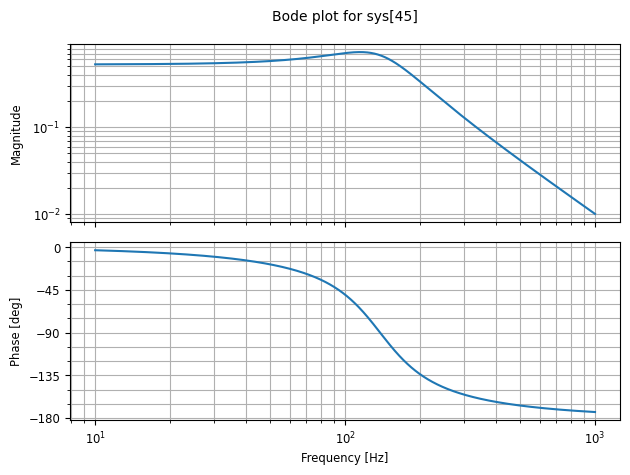

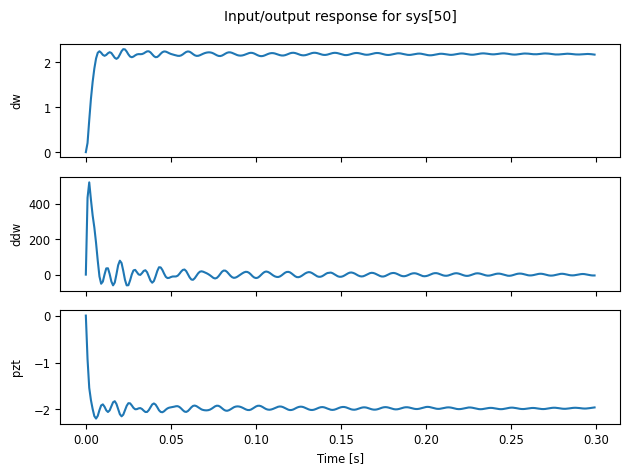

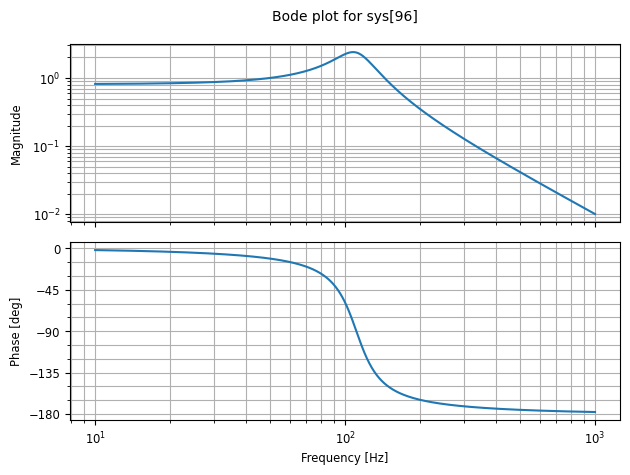

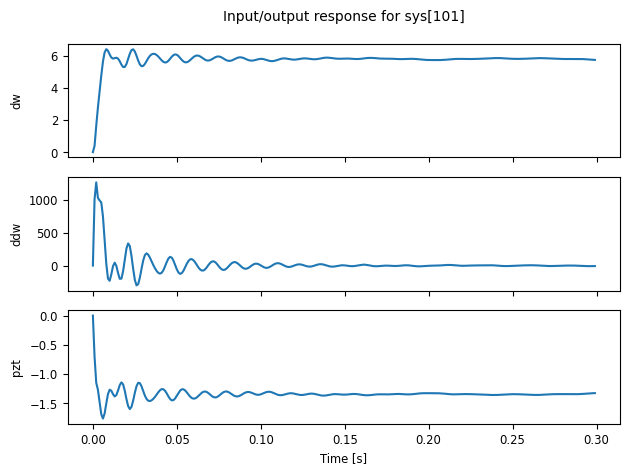

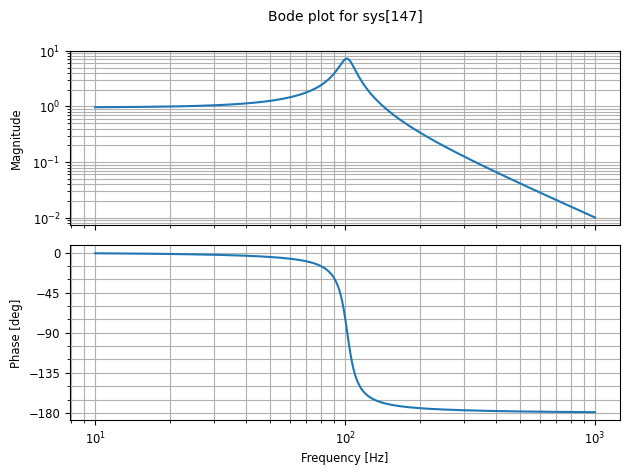

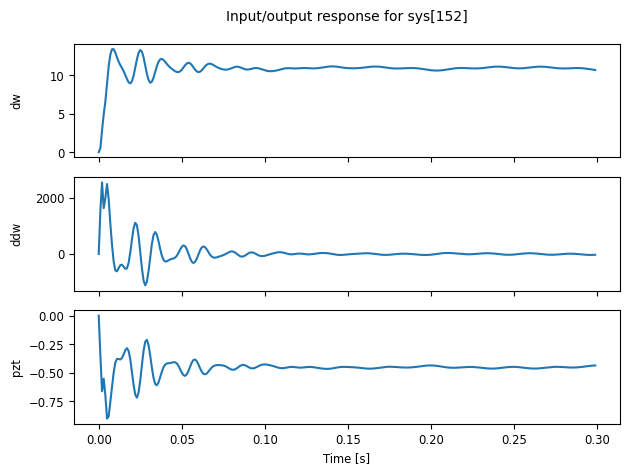

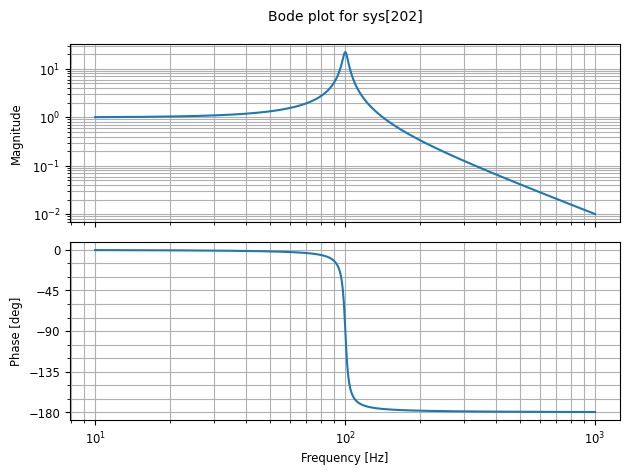

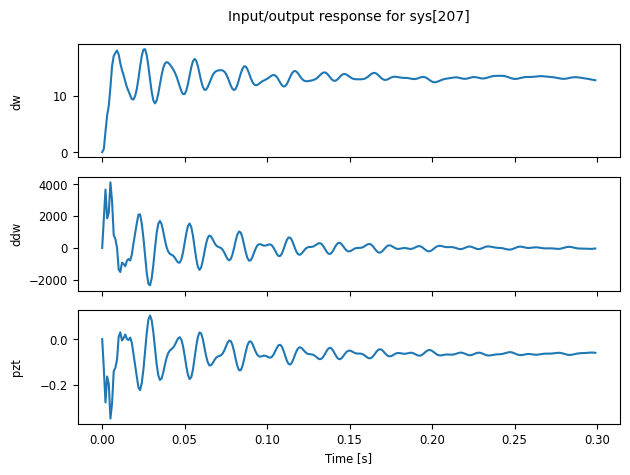

In [6]:
timeseries_nsample = 300
skip_nsample = 100
timestep = 0.001
t = np.arange(0., timeseries_nsample*timestep, timestep)

data = []

# --! define mechanical modes that perturb our cavity
mechanical_mode = namedtuple('mechanical_mode', 'f q k t')
mm100 = mechanical_mode(100.0, 1000.0, 1., [-1., -1.])
mm40 = mechanical_mode(40.0, 400.0, 0.1, [-1., -1.])
mm20 = mechanical_mode(20.0, 200.0, 0.05, [-1., -1.])
mm10 = mechanical_mode(10.0, 100.0, 0.1, [-1., -1.])
mm285 = mechanical_mode(285.0, 1000.0, 1.5, [-1., -1.])
mm64 = mechanical_mode(64.0, 600.0, 3., [-1., -1.])

# --! set flags and parameters for simulation
sim_skipped = [True, True, True, False]
lqr_r = [1.0, 10.0, 100.0, 1000.0]
lqr_used = [True, True, True, True]

for skipped, r, used in zip(sim_skipped, lqr_r, lqr_used):

    if not skipped:
        data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm100.f]),
                mm_q=np.array([mm100.q]),
                mm_k=np.array([mm100.k]),
                mm_t=np.array([mm100.t]),
                plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm40.f]),
            mm_q=np.array([mm40.q]),
            mm_k=np.array([mm40.k]),
            mm_t=np.array([mm40.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm20.f]),
            mm_q=np.array([mm20.q]),
            mm_k=np.array([mm20.k]),
            mm_t=np.array([mm20.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm10.f]),
            mm_q=np.array([mm10.q]),
            mm_k=np.array([mm10.k]),
            mm_t=np.array([mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm10.f]),
            mm_q=np.array([mm100.q, mm10.q]),
            mm_k=np.array([mm100.k, mm10.k]),
            mm_t=np.array([mm100.t, mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm20.f]),
            mm_q=np.array([mm100.q, mm20.q]),
            mm_k=np.array([mm100.k, mm20.k]),
            mm_t=np.array([mm100.t, mm20.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f]),
            mm_q=np.array([mm100.q, mm40.q]),
            mm_k=np.array([mm100.k, mm40.k]),
            mm_t=np.array([mm100.t, mm40.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm10.f]),
            mm_q=np.array([mm100.q, mm40.q, mm10.q]),
            mm_k=np.array([mm100.k, mm40.k, mm10.k]),
            mm_t=np.array([mm100.t, mm40.t, mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm20.f]),
            mm_q=np.array([mm100.q, mm40.q, mm20.q]),
            mm_k=np.array([mm100.k, mm40.k, mm20.k]),
            mm_t=np.array([mm100.t, mm40.t, mm20.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm20.f, mm10.f]),
            mm_q=np.array([mm100.q, mm20.q, mm10.q]),
            mm_k=np.array([mm100.k, mm20.k, mm10.k]),
            mm_t=np.array([mm100.t, mm20.t, mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm20.f, mm10.f]),
            mm_q=np.array([mm100.q, mm40.q, mm20.q, mm10.q]),
            mm_k=np.array([mm100.k, mm40.k, mm20.k, mm10.k]),
            mm_t=np.array([mm100.t, mm40.t, mm20.t, mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm20.f, mm10.f]),
            mm_q=np.array([mm100.q, mm40.q, mm20.q, mm10.q]),
            mm_k=np.array([mm100.k, mm40.k, mm20.k, mm10.k]),
            mm_t=np.array([mm100.t, mm40.t, mm20.t, mm10.t]),
            plotted=False))

    data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm20.f, mm10.f, mm285.f, mm64.f]),
            mm_q=np.array([mm100.q, mm40.q, mm20.q, mm10.q, mm285.q, mm64.q]),
            mm_k=np.array([mm100.k, mm40.k, mm20.k, mm10.k, mm285.k, mm64.k]),
            mm_t=np.array([mm100.t, mm40.t, mm20.t, mm10.t, mm285.t, mm64.t]),
            plotted=True))


In [8]:
# --! save simulated data --!

datasaved = True

if datasaved:
    savedata = np.concatenate(data, axis=0)
    print(f'inf > saved data shape is {savedata.shape}')
    savedir = '../../data/delay'
    utils_data.write_datafile(f'{savedir}/tesla_sim', savedata)

inf > saved data shape is (49, 200, 2)
